<a href="https://colab.research.google.com/github/Ja4yJa5y/ML-Final-Project-/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Acquisition and Preprocessing


In [4]:
# DATA ACQUISITION AND PREPROCESSING
# User Behavioral Anomaly Detection

# Import required libraries
import pandas as pd
import numpy as np
import glob

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


# STEP 1: LOAD DATASETS

# Load psychometric personality traits dataset
psychometric = pd.read_csv("psychometric.csv")

# Load user logon activity dataset
logon = pd.read_csv("logon.csv")

# Load all monthly LDAP files (18 files)
ldap_files = sorted(glob.glob("20*.csv"))

ldap_list = []

for file in ldap_files:
    temp = pd.read_csv(file)
    temp["source_month"] = file.replace(".csv", "")
    ldap_list.append(temp)

# Combine all LDAP files into one dataset
ldap = pd.concat(ldap_list, ignore_index=True)


# STEP 2: DATA CLEANING

print("Before Cleaning")
print(f"Psychometric Shape: {psychometric.shape}")
print(f"Logon Shape: {logon.shape}")
print(f"LDAP Shape: {ldap.shape}")

# Remove duplicate records
psychometric = psychometric.drop_duplicates()
logon = logon.drop_duplicates()
ldap = ldap.drop_duplicates()

# Remove rows with missing values in logon data
logon = logon.dropna()

print("\nAfter Cleaning")
print(f"Psychometric Shape: {psychometric.shape}")
print(f"Logon Shape: {logon.shape}")
print(f"LDAP Shape: {ldap.shape}")


# STEP 3: DATETIME CONVERSION

# Convert date column into datetime format
logon["date"] = pd.to_datetime(logon["date"])

# Extract useful temporal information
logon["hour"] = logon["date"].dt.hour
logon["day_of_week"] = logon["date"].dt.dayofweek
logon["month"] = logon["date"].dt.month


# STEP 4: CREATE TEMPORAL FEATURES

# Identify weekend activity: Saturday = 5, Sunday = 6
logon["is_weekend"] = (
    logon["day_of_week"].isin([5, 6])
).astype(int)

# Identify activity outside normal working hours
# Working hours assumed to be between 8 AM and 6 PM
logon["is_after_hours"] = (
    (logon["hour"] < 8) |
    (logon["hour"] > 18)
).astype(int)


# STEP 5: BEHAVIORAL FEATURE ENGINEERING

# Generate user-level behavioral statistics from logon records
logon_features = logon.groupby("user").agg(
    total_logons=("user", "count"),
    avg_logon_hour=("hour", "mean"),
    after_hours_logons=("is_after_hours", "sum"),
    weekend_logons=("is_weekend", "sum"),
    active_months=("month", "nunique")
).reset_index()

# Calculate ratio of after-hours activity
logon_features["after_hours_ratio"] = (
    logon_features["after_hours_logons"] /
    logon_features["total_logons"]
)

# Calculate ratio of weekend activity
logon_features["weekend_ratio"] = (
    logon_features["weekend_logons"] /
    logon_features["total_logons"]
)

# Rename user column for merging consistency
logon_features = logon_features.rename(
    columns={"user": "user_id"}
)


# STEP 6: LDAP FEATURE AGGREGATION

# Keep the latest organizational information for each user
ldap_features = ldap.groupby("user_id").agg({
    "role": "last",
    "business_unit": "last",
    "functional_unit": "last",
    "department": "last",
    "team": "last",
    "supervisor": "last"
}).reset_index()


# STEP 7: DATA INTEGRATION

# Merge psychometric and LDAP information
merged_data = psychometric.merge(
    ldap_features,
    on="user_id",
    how="inner"
)

# Merge logon behavioral features
merged_data = merged_data.merge(
    logon_features,
    on="user_id",
    how="inner"
)


# STEP 8: HANDLE REMAINING MISSING VALUES

# Replace missing categorical values using the most frequent value
categorical_missing = [
    "functional_unit",
    "department",
    "team",
    "supervisor"
]

for col in categorical_missing:
    merged_data[col] = merged_data[col].fillna(
        merged_data[col].mode()[0]
    )


# STEP 9: ENCODE CATEGORICAL FEATURES

# Convert text categories into numeric values
categorical_columns = [
    "employee_name",
    "user_id",
    "role",
    "functional_unit",
    "department",
    "team",
    "supervisor"
]

for col in categorical_columns:
    le = LabelEncoder()
    merged_data[col] = le.fit_transform(
        merged_data[col].astype(str)
    )


# STEP 10: PREPARE MODEL INPUT DATA

# Remove identifiers that should not be used during model training
model_data = merged_data.drop(
    columns=["employee_name", "user_id"]
)

print("\nModel Data Shape")
print(model_data.shape)


# STEP 11: FEATURE SCALING

# Standardize all features to mean = 0 and standard deviation = 1
scaler = StandardScaler()

scaled_data = pd.DataFrame(
    scaler.fit_transform(model_data),
    columns=model_data.columns
)


# STEP 12: SAVE PROCESSED DATASETS

# Save merged dataset with identifiers for later user mapping
merged_data.to_csv(
    "merged_user_behavior_with_ids.csv",
    index=False
)

# Save cleaned dataset before scaling
model_data.to_csv(
    "model_data.csv",
    index=False
)

# Save final scaled dataset used for ML models
scaled_data.to_csv(
    "preprocessed_user_behavior.csv",
    index=False
)


# STEP 13: PREPROCESSING SUMMARY

print("=" * 60)
print("DATA ACQUISITION AND PREPROCESSING SUMMARY")
print("=" * 60)

print("\nOriginal Datasets")
print(f"Psychometric Shape: {psychometric.shape}")
print(f"Logon Shape: {logon.shape}")
print(f"LDAP Shape: {ldap.shape}")

print("\nLDAP Files Loaded")
print(f"Number of LDAP Files: {len(ldap_files)}")

print("\nMerged Dataset")
print(f"Merged Shape: {merged_data.shape}")

print("\nData Quality Checks")
print(f"Total Missing Values: {merged_data.isnull().sum().sum()}")
print(f"Duplicate Rows: {merged_data.duplicated().sum()}")

print("\nFinal Modeling Dataset")
print(f"Scaled Data Shape: {scaled_data.shape}")
print(f"Number of Users: {scaled_data.shape[0]}")
print(f"Number of Features: {scaled_data.shape[1]}")

print("\nBehavioral Features Generated")
print("- total_logons")
print("- avg_logon_hour")
print("- after_hours_logons")
print("- weekend_logons")
print("- active_months")
print("- after_hours_ratio")
print("- weekend_ratio")

print("\nPreview of Final Dataset")
display(scaled_data.head())

print("\nFiles Saved Successfully")
print("1. merged_user_behavior_with_ids.csv")
print("2. model_data.csv")
print("3. preprocessed_user_behavior.csv")

print("\nPreprocessing Completed Successfully")
print("=" * 60)

Before Cleaning
Psychometric Shape: (4000, 7)
Logon Shape: (3530285, 5)
LDAP Shape: (68923, 11)

After Cleaning
Psychometric Shape: (4000, 7)
Logon Shape: (3530285, 5)
LDAP Shape: (68923, 11)

Model Data Shape
(4000, 18)
DATA ACQUISITION AND PREPROCESSING SUMMARY

Original Datasets
Psychometric Shape: (4000, 7)
Logon Shape: (3530285, 10)
LDAP Shape: (68923, 11)

LDAP Files Loaded
Number of LDAP Files: 18

Merged Dataset
Merged Shape: (4000, 20)

Data Quality Checks
Total Missing Values: 0
Duplicate Rows: 0

Final Modeling Dataset
Scaled Data Shape: (4000, 18)
Number of Users: 4000
Number of Features: 18

Behavioral Features Generated
- total_logons
- avg_logon_hour
- after_hours_logons
- weekend_logons
- active_months
- after_hours_ratio
- weekend_ratio

Preview of Final Dataset


,O,C,E,A,N,role,business_unit,functional_unit,department,team,supervisor,total_logons,avg_logon_hour,after_hours_logons,weekend_logons,active_months,after_hours_ratio,weekend_ratio
0,0.078081,0.718616,0.810750,0.627225,-1.722926,-0.815592,0.0,-1.717848,1.703985,1.686898,0.244375,5.467969,-0.680513,5.688960,-0.278389,0.212012,1.622154,-0.301805
1,0.267770,0.718616,-1.434721,-0.913534,-0.514703,0.152374,0.0,0.264894,-0.793713,0.320483,0.344513,0.253961,-0.654917,0.128940,-0.278389,0.212012,0.098297,-0.301805
2,-0.585831,-1.561258,1.349663,-0.641635,0.894891,0.152374,0.0,0.661443,-0.793713,-0.811689,-0.327840,-0.414813,0.482927,-0.856808,-0.278389,0.212012,-1.295533,-0.301805
3,0.172925,1.630566,-0.626352,1.442921,-0.313333,0.152374,0.0,0.661443,-0.793713,1.569776,-0.871445,0.253961,0.072848,-0.293041,-0.278389,0.212012,-0.498377,-0.301805
4,-1.723964,-1.470063,1.080206,0.899123,-0.514703,-0.250945,0.0,-0.528202,0.871419,-0.694568,-0.699780,-0.414813,-0.218542,0.344994,-0.278389,0.212012,1.060135,-0.301805



Files Saved Successfully
1. merged_user_behavior_with_ids.csv
2. model_data.csv
3. preprocessed_user_behavior.csv

Preprocessing Completed Successfully


**Data Split**

In [7]:
from sklearn.model_selection import train_test_split

# 1. Extract the raw numerical values from the preprocessing output
X_tabular = scaled_data.values

# 2. Implement the clean 80/20 train/test partition split
X_train_tabular, X_test_tabular = train_test_split(X_tabular, test_size=0.20, random_state=42)

print("=" * 60)
print("DATASET PARTITIONING COMPLETE (80/20 SPLIT)")
print("=" * 60)
print(f"Total Preprocessed Roster: {X_tabular.shape[0]} users")
print(f"Training Allocation (80%):  {X_train_tabular.shape[0]} users (For Model Development)")
print(f"Testing Allocation (20%):   {X_test_tabular.shape[0]} users (For Evaluation & Analysis)")

DATASET PARTITIONING COMPLETE (80/20 SPLIT)
Total Preprocessed Roster: 4000 users
Training Allocation (80%):  3200 users (For Model Development)
Testing Allocation (20%):   800 users (For Evaluation & Analysis)


**LSTM Autoencoder Model Development and Training**

Epoch 1/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.9153 - val_loss: 0.8188
Epoch 2/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5958 - val_loss: 0.4084
Epoch 3/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2888 - val_loss: 0.2069
Epoch 4/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1568 - val_loss: 0.1273
Epoch 5/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1044 - val_loss: 0.0936
Epoch 6/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0785 - val_loss: 0.0741
Epoch 7/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0625 - val_loss: 0.0610
Epoch 8/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0512 - val_loss: 0.0516
Epoch 9/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0429 - val_loss: 0.0426
Epoch 10/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0360 - val_loss: 0.0366
Epoch 11/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0301 - val_loss: 0.0310
Epoch 12/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0256 - val_lo

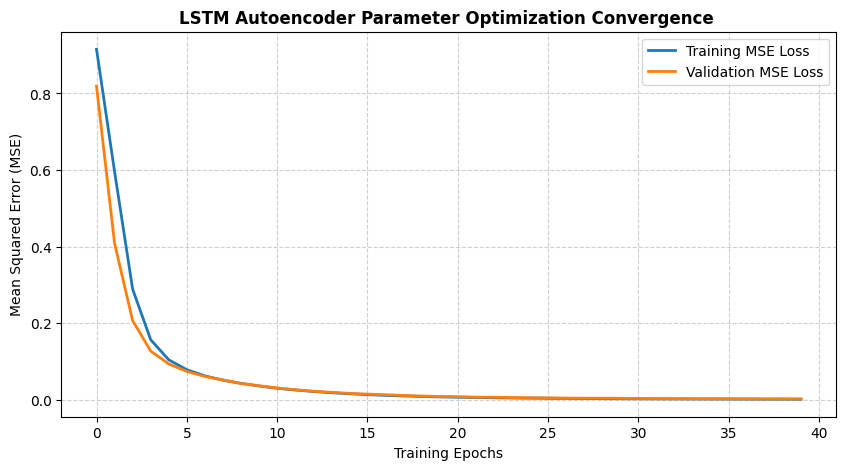

TRAINING STATUS: Complete. Model saved as 'lstm_autoencoder_trained.keras'


In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
import matplotlib.pyplot as plt

# 1. Reshape 2D training data into 3D tensor for LSTM input (samples, time_steps, features)
X_train_seq = np.reshape(X_train_tabular, (X_train_tabular.shape[0], 1, X_train_tabular.shape[1]))

TIME_STEPS = X_train_seq.shape[1]
NUM_FEATURES = X_train_seq.shape[2]

# 2. Define LSTM Autoencoder network architecture
model = Sequential([
    Input(shape=(TIME_STEPS, NUM_FEATURES)),
    LSTM(32, activation='relu', return_sequences=False),
    RepeatVector(TIME_STEPS),
    LSTM(32, activation='relu', return_sequences=True),
    TimeDistributed(Dense(NUM_FEATURES))
])

# 3. Compile model with Adam optimizer and Mean Squared Error loss
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# 4. Train the model on the preprocessed training dataset
history = model.fit(
    X_train_seq, X_train_seq,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

# 5. Plot training and validation loss curves over epochs
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], linewidth=2, label='Training MSE Loss')
plt.plot(history.history['val_loss'], linewidth=2, label='Validation MSE Loss')
plt.title('LSTM Autoencoder Parameter Optimization Convergence ', fontsize=12, fontweight='bold')
plt.xlabel('Training Epochs', fontsize=10)
plt.ylabel('Mean Squared Error (MSE)', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 6. Export the trained model state to a native Keras file
model.save('lstm_autoencoder_trained.keras')

print("=" * 60)
print("TRAINING STATUS: Complete. Model saved as 'lstm_autoencoder_trained.keras'")
print("=" * 60)